## Polynomial Regression on Boston Housing Dataset

**In this notebook we do a comparative study of Linear Regression and Polynomial Regression accuracy on the Boston Housing Dataset**

This data was originally a part of UCI Machine Learning Repository and has been removed now. This data also ships with the scikit-learn library. 
There are 506 samples and 13 feature variables in this data-set. The objective is to predict the value of prices of the house using the given features.

The description of all the features is given below:

  **CRIM**: Per capita crime rate by town

  **ZN**: Proportion of residential land zoned for lots over 25,000 sq. ft

  **INDUS**: Proportion of non-retail business acres per town

  **CHAS**: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)

  **NOX**: Nitric oxide concentration (parts per 10 million)

  **RM**: Average number of rooms per dwelling

  **AGE**: Proportion of owner-occupied units built prior to 1940

  **DIS**: Weighted distances to five Boston employment centers

  **RAD**: Index of accessibility to radial highways

  **TAX**: Full-value property tax rate per $10,000

  **B**: 1000(Bk - 0.63)², where Bk is the proportion of [people of African American descent] by town

  **LSTAT**: Percentage of lower status of the population

  **MEDV**: Median value of owner-occupied homes in $1000s
  
  
  



I**mport the required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Load the data into pandas dataframe . Load the Boston Housing DataSet from data/boston_house_prices.csv**

In [2]:
boston = pd.read_csv('data/boston_house_prices.csv')
boston.head()

,506,13,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
1,0.00632,18,2.31,0,0.538,6.575,65.2,4.09,1,296,15.3,396.9,4.98,24
2,0.02731,0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14,21.6
3,0.02729,0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
4,0.03237,0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4


**Data preprocessing**

Check for missing values in all the columns

In [3]:
boston.isnull().sum() 

506            0
13             0
Unnamed: 2     0
Unnamed: 3     0
Unnamed: 4     0
Unnamed: 5     0
Unnamed: 6     0
Unnamed: 7     0
Unnamed: 8     0
Unnamed: 9     0
Unnamed: 10    0
Unnamed: 11    0
Unnamed: 12    0
Unnamed: 13    0
dtype: int64

**Data Visualization**

In [ ]:
boston.columns = boston.iloc[0]
boston = boston[1:].reset_index(drop=True)          ##hay que cambiar los numeros a float!!!, estan en string
boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18,2.31,0,0.538,6.575,65.2,4.09,1,296,15.3,396.9,4.98,24
1,0.02731,0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14,21.6
2,0.02729,0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.9,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21,391.99,9.67,22.4
502,0.04527,0,11.93,0,0.573,6.12,76.7,2.2875,1,273,21,396.9,9.08,20.6
503,0.06076,0,11.93,0,0.573,6.976,91,2.1675,1,273,21,396.9,5.64,23.9
504,0.10959,0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21,393.45,6.48,22


<Axes: xlabel='0', ylabel='0'>

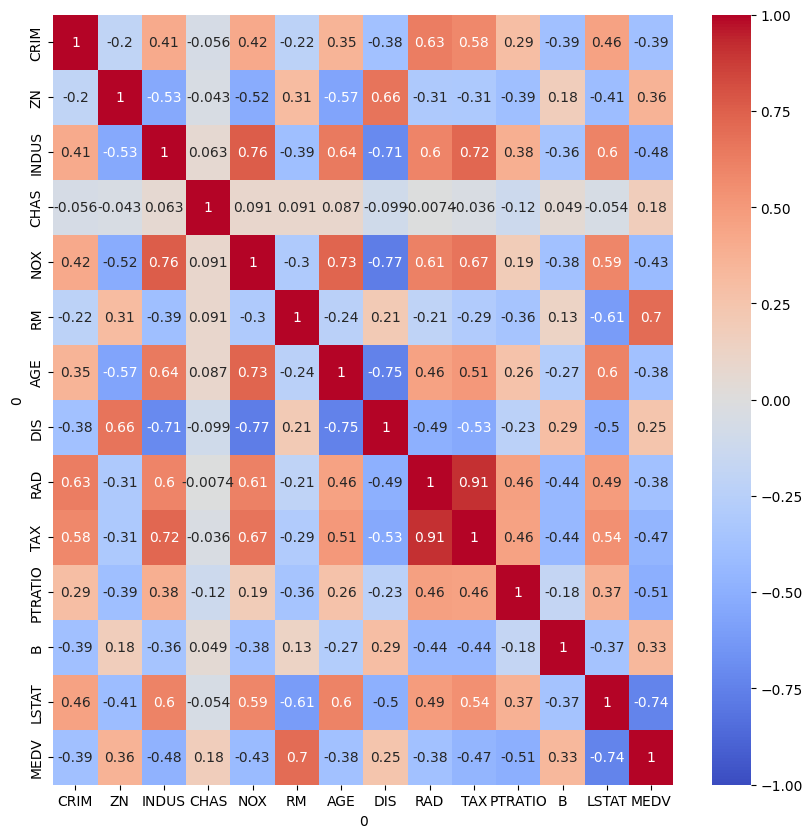

In [14]:
plt.figure(figsize=(10,10))
sns.heatmap(boston.corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm") 

In [ ]:
##las colinearidades negativas tb hay que considerarlas!!

**Correlation matrix**

Analyze the correlation matrix. Plot a heatmap

* From correlation plot: which are the columns that are more correlated with **MEDV**
* There are two features highly correlated. Identify them and drop one of them in order to avoid multi-colinearity

Correlated with MEDV: RM (0.7), LSTAT (-0.74)

### Draw 2 scatter plots to see the relationship between **MEDV** and **LSTAT** and **RM**

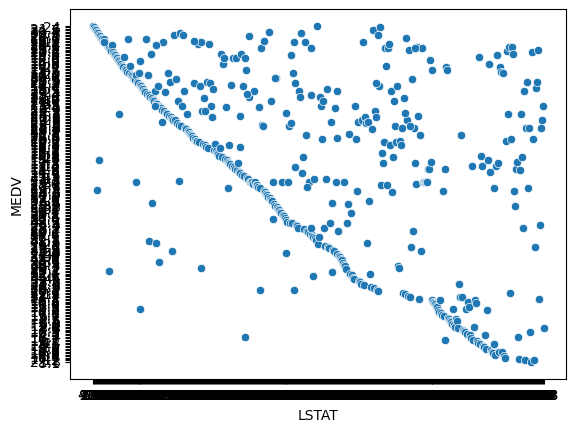

In [35]:
sns.scatterplot(x=boston['LSTAT'], y=boston['MEDV']);

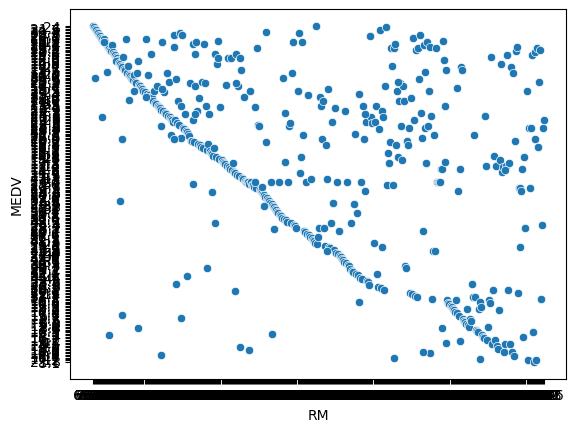

In [33]:
sns.scatterplot(x=boston['RM'], y=boston['MEDV']);

**Prepare the data for training**
Create a dataframe X including **LSTAT** and **RM** columns.
Y should be a pandas series including target values **'MEDV'**


In [1]:
X = boston[['LSTAT', 'RM']]
X

NameError: name 'boston' is not defined

In [26]:
y = boston['MEDV']

**Split the data into training and testing sets**

Splits the training and test data set in 80% : 20%. Assign random_state to any value. This ensures consistency. Print the sahes of the resulting objects

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42) 

In [28]:
print("Total features shape:", X.shape)
print("Train features shape:", X_train.shape)
print("Train target shape:", y_train.shape)
print("Test features shape:", X_test.shape)
print("Test target shape:", y_test.shape)

Total features shape: (506, 3)
Train features shape: (404, 3)
Train target shape: (404,)
Test features shape: (102, 3)
Test target shape: (102,)


# **Linear Regression**

Build a linear regression model with sklearn LinearRegression.
We'll use Mean Squared error and R2 score to evaluate our model, so be sure to make the needed imports.

Import the necessary functions and train a LinearRegression model

In [36]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Evaluate the model performance in the training and testing sets**

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
y_pred_test = lin_reg.predict(X_test)

print("R2 score test", lin_reg.score(X_test, y_test))
print("MAE test", mean_absolute_error(y_test, y_pred_test))
print("MSE test", mean_squared_error(y_test, y_pred_test))

In [ ]:
y_pred_train = lin_reg.predict(X_train)

print("R2 score train", lin_reg.score(X_train, y_train))
print("MAE train", mean_absolute_error(y_train, y_pred_train))
print("MSE train", mean_squared_error(y_train, y_pred_train))

**Lets see the model performance visually. Let's plot y_test vs y_pred**

Plotting the y_test vs y_pred. Ideally should have been a straight line

In [ ]:
sns.regplot(x=y_test, y=y_pred_test)

# **Polynomial Regression**

We can see that **LSTAT** doesn't vary exactly in a linear way. Let's apply the Polynomial Regression with **degree 2** and test. 

To generate the higher order degrees, we use PolyniomialFeatures class from sklearn library. 

In [47]:
from sklearn.preprocessing import PolynomialFeatures

poly_reg = PolynomialFeatures(degree=2)
poly_reg.fit(X_train)
X_train_poly = poly_reg.transform(X_train)
X_test_poly = poly_reg.transform(X_test)

In [48]:
np.shape(X_train)

(404, 3)

In [49]:
np.shape(X_train_poly)

(404, 10)

In [50]:
pol_reg_2 = LinearRegression()
pol_reg_2.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Did the model improve using the Polynomial model?**

In [51]:
y_pred_test = pol_reg_2.predict(X_test_poly)

print("R2 score test", pol_reg_2.score(X_test_poly, y_test))
print("MAE test", mean_absolute_error(y_test, y_pred_test))
print("MSE test", mean_squared_error(y_test, y_pred_test))

R2 score test 1.0
MAE test 4.996438992391489e-14
MSE test 6.384529727449609e-27


In [52]:
y_pred_train = pol_reg_2.predict(X_train_poly)

print("R2 score train", pol_reg_2.score(X_train_poly, y_train))
print("MAE train", mean_absolute_error(y_train, y_pred_train))
print("MSE train", mean_squared_error(y_train, y_pred_train))

R2 score train 1.0
MAE train 5.674448809623746e-14
MSE train 7.640029998895363e-27


**Did the model improve using the Polynomial model with degree 3? Or more?**

In [53]:
poly_reg = PolynomialFeatures(degree=3)
poly_reg.fit(X_train)
X_train_poly = poly_reg.transform(X_train)
X_test_poly = poly_reg.transform(X_test)

pol_reg_3 = LinearRegression()
pol_reg_3.fit(X_train_poly, y_train)

y_pred_test = pol_reg_3.predict(X_test_poly)

print("R2 score test", pol_reg_3.score(X_test_poly, y_test))
print("MAE test", mean_absolute_error(y_test, y_pred_test))
print("MSE test", mean_squared_error(y_test, y_pred_test))

y_pred_train = pol_reg_3.predict(X_train_poly)

print("R2 score train", pol_reg_3.score(X_train_poly, y_train))
print("MAE train", mean_absolute_error(y_train, y_pred_train))
print("MSE train", mean_squared_error(y_train, y_pred_train))

R2 score test 1.0
MAE test 2.552598655323463e-12
MSE test 1.5617059704210976e-23
R2 score train 1.0
MAE train 2.6236240902582976e-12
MSE train 1.6353859018220492e-23


In [54]:
np.shape(X_train_poly)

(404, 20)

In [55]:
poly_reg = PolynomialFeatures(degree=4)
poly_reg.fit(X_train)
X_train_poly = poly_reg.transform(X_train)
X_test_poly = poly_reg.transform(X_test)

pol_reg_4 = LinearRegression()
pol_reg_4.fit(X_train_poly, y_train)

y_pred_test = pol_reg_4.predict(X_test_poly)

print("R2 score test", pol_reg_4.score(X_test_poly, y_test))
print("MAE test", mean_absolute_error(y_test, y_pred_test))
print("MSE test", mean_squared_error(y_test, y_pred_test))

y_pred_train = pol_reg_4.predict(X_train_poly)

print("R2 score train", pol_reg_4.score(X_train_poly, y_train))
print("MAE train", mean_absolute_error(y_train, y_pred_train))
print("MSE train", mean_squared_error(y_train, y_pred_train))

R2 score test 1.0
MAE test 1.1450073133642928e-10
MSE test 2.1401698703922734e-20
R2 score train 1.0
MAE train 1.1319449228326988e-10
MSE train 1.9988723927686152e-20


In [56]:
np.shape(X_train_poly)

(404, 35)

In [ ]:
#rm = float(input("Introduce la variable de RM"))
#lstat = float(input("Introduce la variable de LSTAT"))

#pol_reg_2.predict(poly_reg.transform([[rm, lstat]]))

In [57]:
from sklearn.model_selection import cross_val_score

In [ ]:
results_cv = cross_val_score(lin_reg, X, y, scoring="neg_mean_absolute_error", cv=10)
print(results_cv)
print(results_cv.mean())
print(results_cv.std())

In [59]:
poly_reg = PolynomialFeatures(degree=2)
poly_reg.fit(X)
X_poly = poly_reg.transform(X)

results_cv = cross_val_score(pol_reg_2, X_poly, y, scoring="neg_mean_absolute_error", cv=10)
print(results_cv)
print(results_cv.mean())
print(results_cv.std())

[-3.34024747e-14 -5.46839262e-14 -6.33915578e-15 -7.34227494e-14
 -4.61852778e-14 -1.98534000e-14 -2.02504680e-14 -4.32009983e-14
 -5.74296166e-14 -4.33253433e-14]
-3.980934100885254e-14
1.915253804014786e-14
